In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Set figure size defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

---
## 1. EEG Data Analysis (EEG_FEP_01_EEGdata.csv)

This file contains the main EEG signal data - time series recordings from multiple electrodes/channels.

In [2]:
# Load EEG data
eeg_data = pd.read_csv('data/EEG_FEP_01_EEGdata.csv', header=None)

# Add column names (Channel 0, Channel 1, etc.)
eeg_data.columns = [f'Channel_{i}' for i in range(eeg_data.shape[1])]

print("=" * 60)
print("EEG DATA - BASIC INFORMATION")
print("=" * 60)
print(f"\nShape: {eeg_data.shape}")
print(f"Number of time samples: {eeg_data.shape[0]}")
print(f"Number of channels: {eeg_data.shape[1]}")
print(f"\nData types:\n{eeg_data.dtypes.value_counts()}")

EEG DATA - BASIC INFORMATION

Shape: (184320, 31)
Number of time samples: 184320
Number of channels: 31

Data types:
float64    31
Name: count, dtype: int64


In [3]:
# Statistical summary of EEG data
print("\n" + "=" * 60)
print("EEG DATA - STATISTICAL SUMMARY")
print("=" * 60)
eeg_stats = eeg_data.describe()
print(eeg_stats)


EEG DATA - STATISTICAL SUMMARY
           Channel_0      Channel_1      Channel_2      Channel_3  \
count  184320.000000  184320.000000  184320.000000  184320.000000   
mean        0.016061       0.011307       0.006596       0.006115   
std        44.409146      39.993655      26.926557      26.473130   
min      -193.060000    -179.910000    -124.640000    -116.880000   
25%       -12.733000     -14.205000      -9.542400      -9.927000   
50%         0.237105       0.386350       0.312640       0.245295   
75%        14.979250      15.557250      10.538000      10.646250   
max       322.560000     294.850000     197.080000     190.280000   

           Channel_4      Channel_5      Channel_6      Channel_7  \
count  184320.000000  184320.000000  184320.000000  184320.000000   
mean       -3.615918       0.002200       0.002090       0.003862   
std      1177.799526      19.080668      20.465454      21.457812   
min    -39202.000000    -152.510000     -98.253000    -129.750000   
2

In [4]:
# Check for missing values
print("\n" + "=" * 60)
print("EEG DATA - MISSING VALUES CHECK")
print("=" * 60)
missing_values = eeg_data.isnull().sum()
print(f"\nTotal missing values: {missing_values.sum()}")
if missing_values.sum() > 0:
    print("\nMissing values per channel:")
    print(missing_values[missing_values > 0])
else:
    print("No missing values found!")


EEG DATA - MISSING VALUES CHECK

Total missing values: 0
No missing values found!


In [5]:
# Per-channel statistics
print("\n" + "=" * 60)
print("EEG DATA - PER CHANNEL STATISTICS")
print("=" * 60)

channel_stats = pd.DataFrame({
    'Mean': eeg_data.mean(),
    'Std': eeg_data.std(),
    'Min': eeg_data.min(),
    'Max': eeg_data.max(),
    'Range': eeg_data.max() - eeg_data.min(),
    'Skewness': eeg_data.skew(),
    'Kurtosis': eeg_data.kurtosis()
})
print(channel_stats)


EEG DATA - PER CHANNEL STATISTICS
                Mean          Std        Min         Max       Range  \
Channel_0   0.016061    44.409146   -193.060     322.560     515.620   
Channel_1   0.011307    39.993655   -179.910     294.850     474.760   
Channel_2   0.006596    26.926557   -124.640     197.080     321.720   
Channel_3   0.006115    26.473130   -116.880     190.280     307.160   
Channel_4  -3.615918  1177.799526 -39202.000  125860.000  165062.000   
Channel_5   0.002200    19.080668   -152.510     145.690     298.200   
Channel_6   0.002090    20.465454    -98.253     150.150     248.403   
Channel_7   0.003862    21.457812   -129.750     158.100     287.850   
Channel_8   0.005004    24.309629   -164.070     186.260     350.330   
Channel_9   0.000935    13.217286   -106.250     122.020     228.270   
Channel_10 -0.000971    15.545989   -102.380     110.740     213.120   
Channel_11  0.024238   282.871149  -3153.600    3189.500    6343.100   
Channel_12  0.001427    20.20

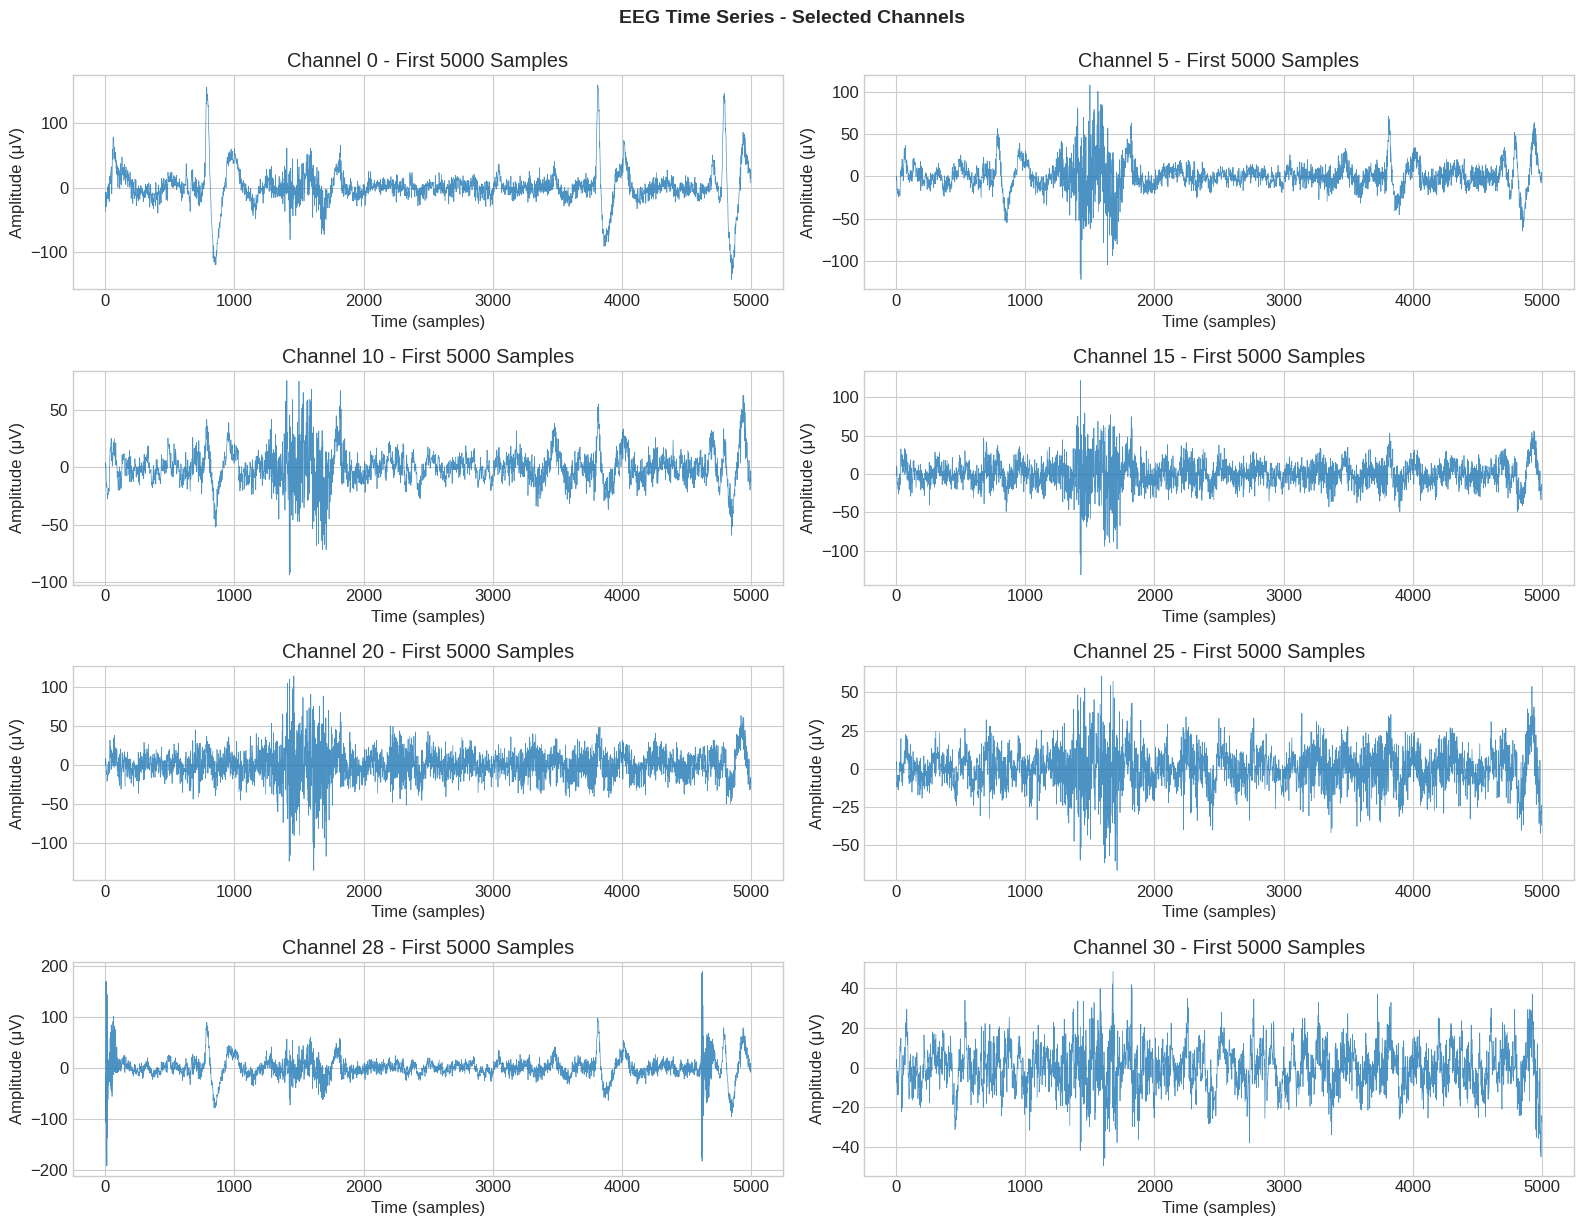

In [6]:
# Visualize time series for selected channels
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
selected_channels = [0, 5, 10, 15, 20, 25, 28, 30]

for idx, ch in enumerate(selected_channels[:8]):
    if ch < eeg_data.shape[1]:
        ax = axes[idx // 2, idx % 2]
        # Plot first 5000 samples for visibility
        ax.plot(eeg_data[f'Channel_{ch}'].iloc[:5000], linewidth=0.5, alpha=0.8)
        ax.set_title(f'Channel {ch} - First 5000 Samples')
        ax.set_xlabel('Time (samples)')
        ax.set_ylabel('Amplitude (μV)')

plt.tight_layout()
plt.suptitle('EEG Time Series - Selected Channels', y=1.02, fontsize=14, fontweight='bold')
plt.show()

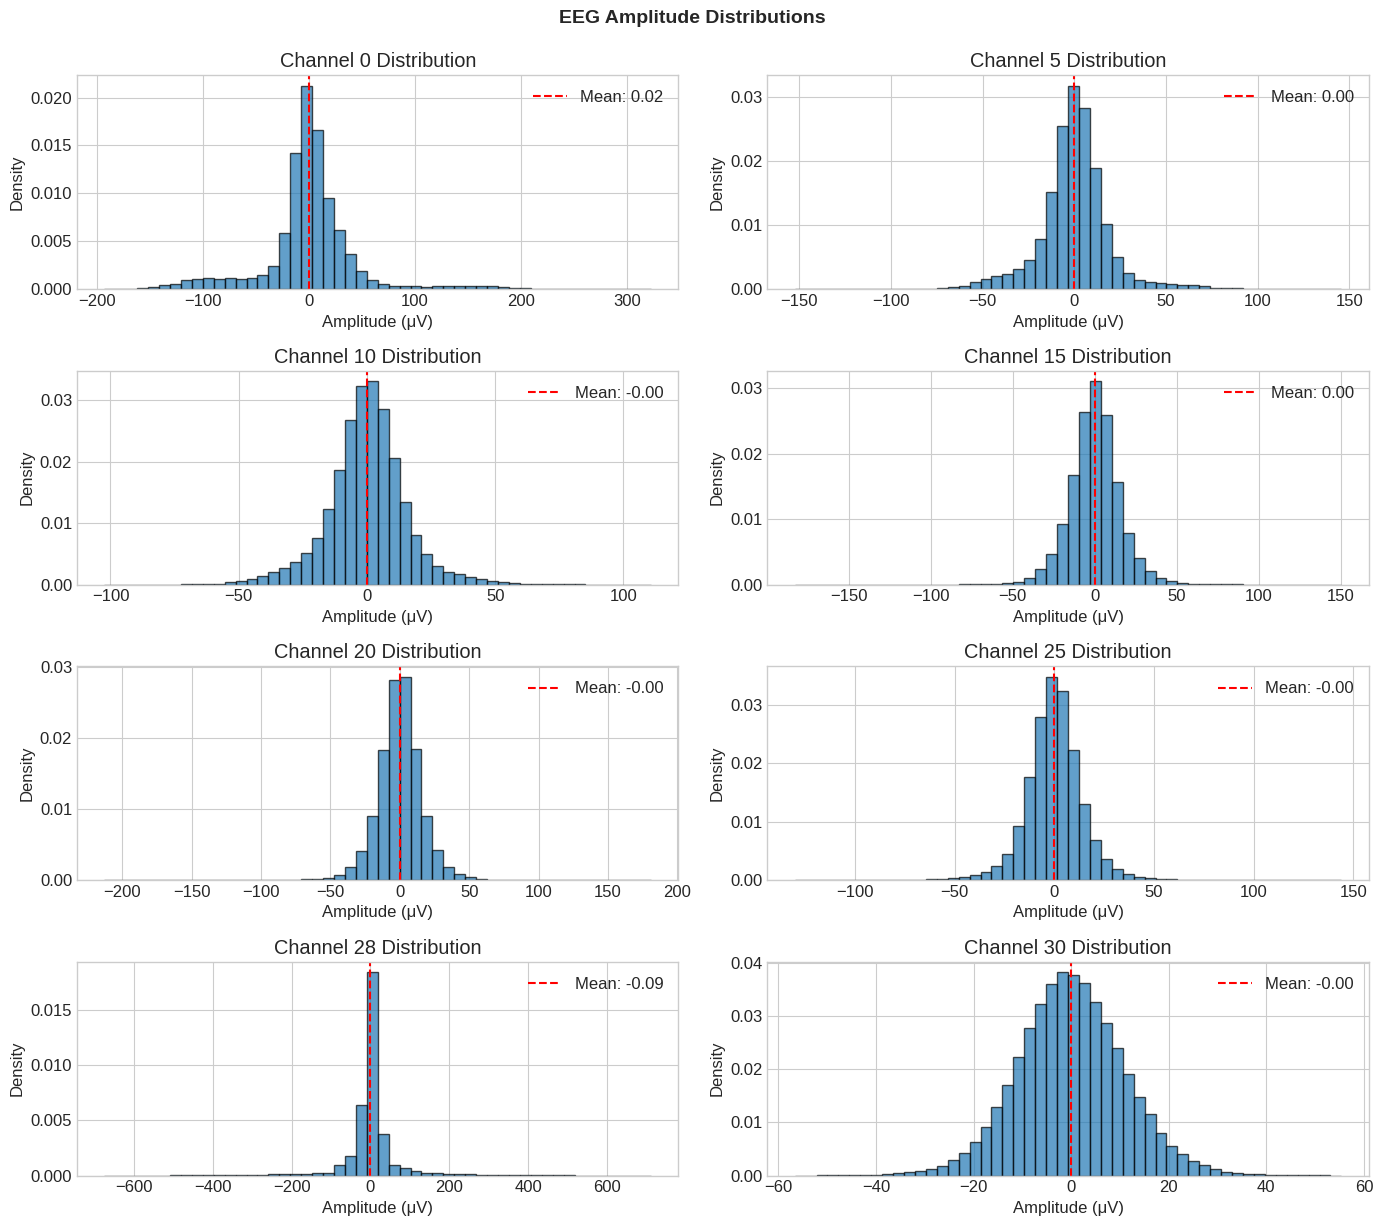

In [7]:
# Distribution analysis - Histograms for selected channels
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

for idx, ch in enumerate(selected_channels[:8]):
    if ch < eeg_data.shape[1]:
        ax = axes[idx // 2, idx % 2]
        ax.hist(eeg_data[f'Channel_{ch}'], bins=50, edgecolor='black', alpha=0.7, density=True)
        ax.set_title(f'Channel {ch} Distribution')
        ax.set_xlabel('Amplitude (μV)')
        ax.set_ylabel('Density')
        
        # Add mean and std lines
        mean_val = eeg_data[f'Channel_{ch}'].mean()
        ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        ax.legend()

plt.tight_layout()
plt.suptitle('EEG Amplitude Distributions', y=1.02, fontsize=14, fontweight='bold')
plt.show()

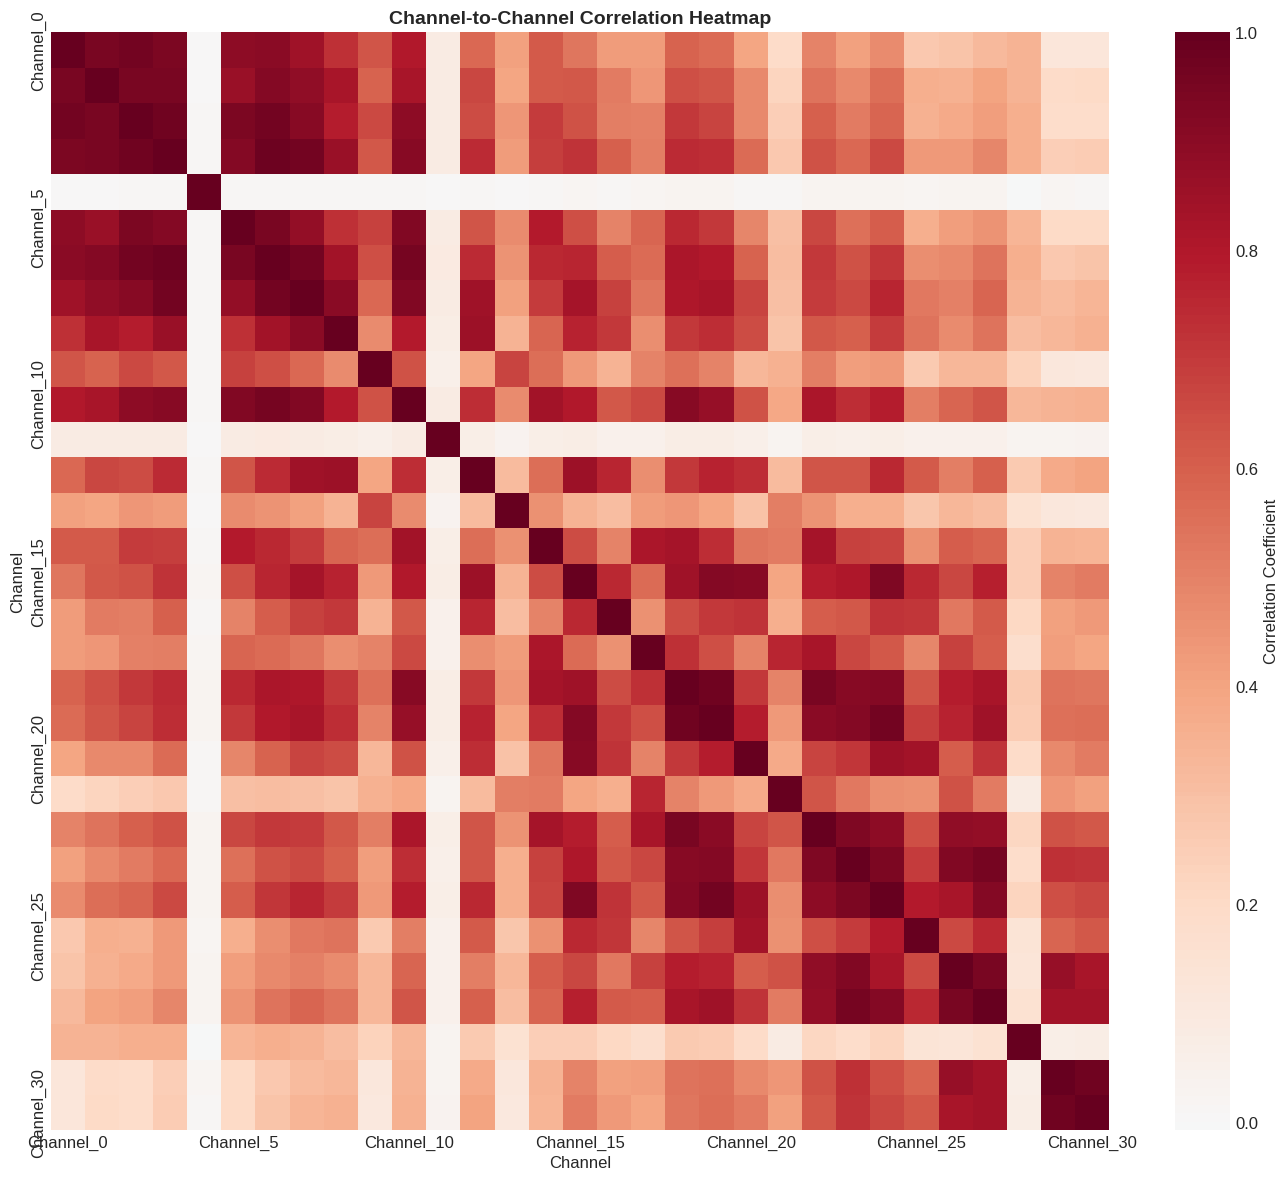

In [8]:
# Channel correlation heatmap
plt.figure(figsize=(14, 12))
correlation_matrix = eeg_data.corr()
sns.heatmap(correlation_matrix, cmap='RdBu_r', center=0, 
            xticklabels=5, yticklabels=5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Channel-to-Channel Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Channel')
plt.tight_layout()
plt.show()

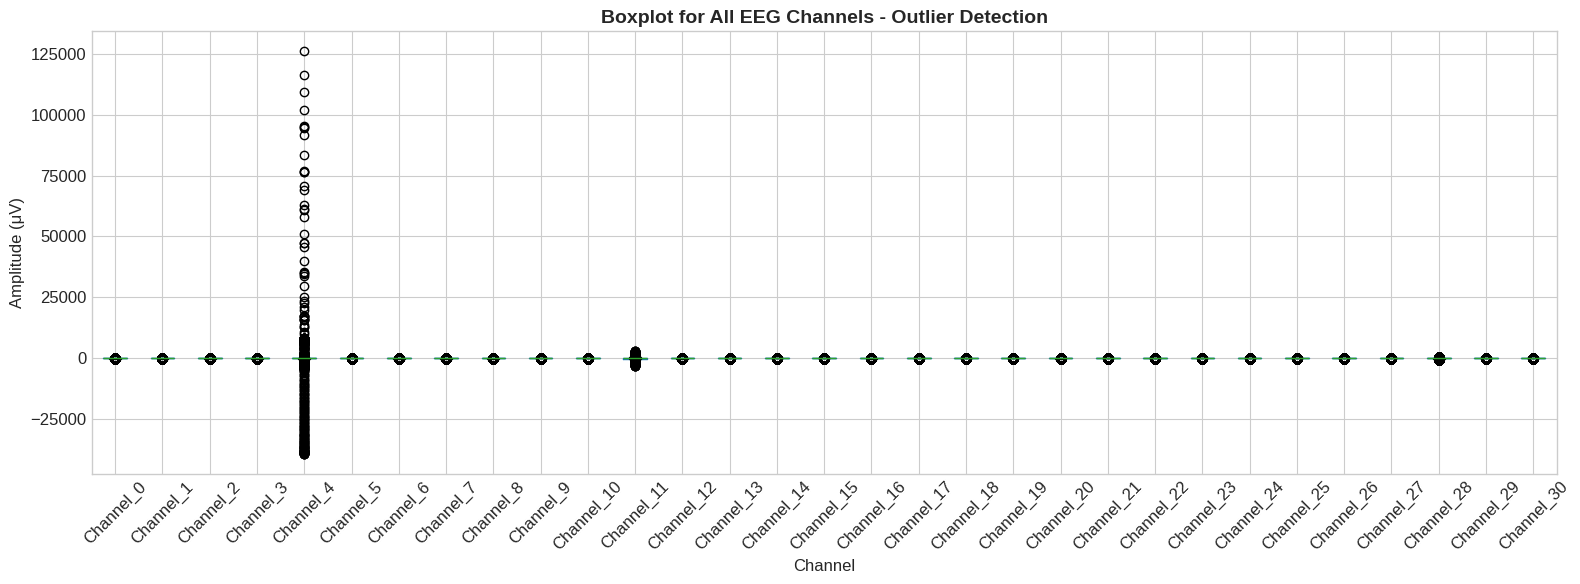

In [9]:
# Boxplot for all channels to detect outliers
plt.figure(figsize=(16, 6))
eeg_data.boxplot(figsize=(16, 6))
plt.title('Boxplot for All EEG Channels - Outlier Detection', fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Amplitude (μV)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


EEG DATA - SIGNAL POWER ANALYSIS


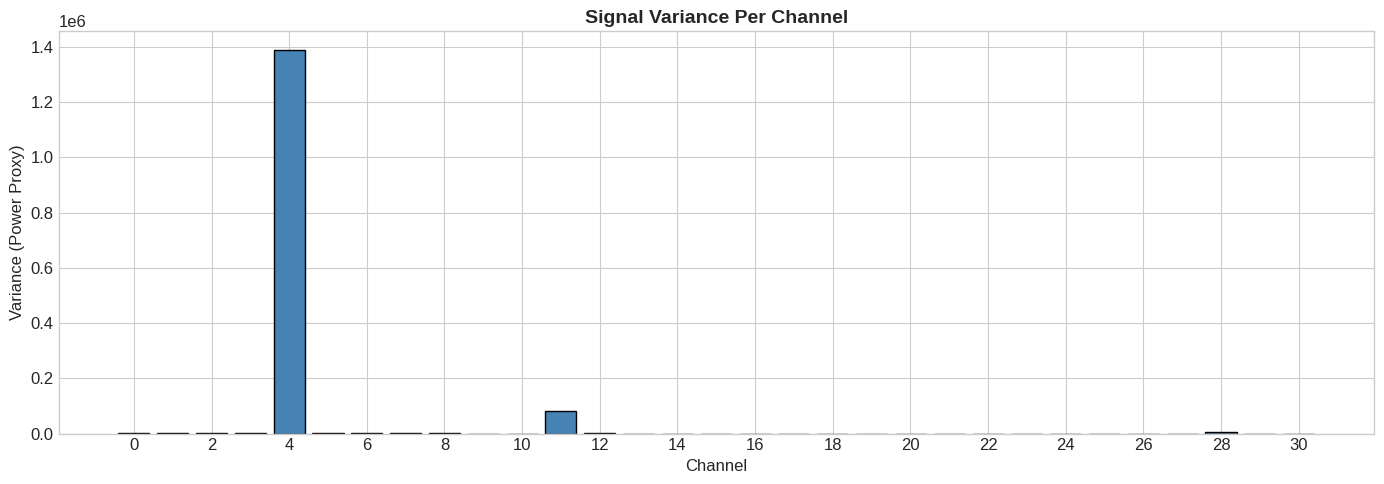


Channel with highest variance: Channel_4 = 1387211.72
Channel with lowest variance: Channel_29 = 122.26


In [10]:
# Global signal power analysis
print("\n" + "=" * 60)
print("EEG DATA - SIGNAL POWER ANALYSIS")
print("=" * 60)

# Calculate variance (power proxy) for each channel
channel_variance = eeg_data.var()

plt.figure(figsize=(14, 5))
plt.bar(range(len(channel_variance)), channel_variance.values, color='steelblue', edgecolor='black')
plt.xlabel('Channel')
plt.ylabel('Variance (Power Proxy)')
plt.title('Signal Variance Per Channel', fontsize=14, fontweight='bold')
plt.xticks(range(0, len(channel_variance), 2))
plt.tight_layout()
plt.show()

print(f"\nChannel with highest variance: Channel_{channel_variance.idxmax().split('_')[1]} = {channel_variance.max():.2f}")
print(f"Channel with lowest variance: Channel_{channel_variance.idxmin().split('_')[1]} = {channel_variance.min():.2f}")

---
## 2. Event Data Analysis (EEG_FEP_01_EEGevent.csv)

This file contains event markers/triggers that occurred during the EEG recording.

In [11]:
# Load event data
event_data = pd.read_csv('data/EEG_FEP_01_EEGevent.csv', header=None)
event_data.columns = ['Sample_Index', 'Event_Type']

print("=" * 60)
print("EVENT DATA - BASIC INFORMATION")
print("=" * 60)
print(f"\nShape: {event_data.shape}")
print(f"Number of events: {len(event_data)}")
print(f"\nData types:\n{event_data.dtypes}")

EVENT DATA - BASIC INFORMATION

Shape: (24, 2)
Number of events: 24

Data types:
Sample_Index    int64
Event_Type      int64
dtype: object


In [12]:
# Display all events
print("\n" + "=" * 60)
print("EVENT DATA - ALL EVENTS")
print("=" * 60)
print(event_data)


EVENT DATA - ALL EVENTS
    Sample_Index  Event_Type
0              1           1
1           7681           1
2          15361           1
3          23041           1
4          30721           1
5          38401           1
6          46081           2
7          53761           2
8          61441           2
9          69121           2
10         76801           2
11         84481           2
12         92161           3
13         99841           3
14        107521           3
15        115201           3
16        122881           3
17        130561           3
18        138241           4
19        145921           4
20        153601           4
21        161281           4
22        168961           4
23        176641           4



EVENT DATA - EVENT TYPE ANALYSIS

Event Type Distribution:
Event_Type
1    6
2    6
3    6
4    6
Name: count, dtype: int64


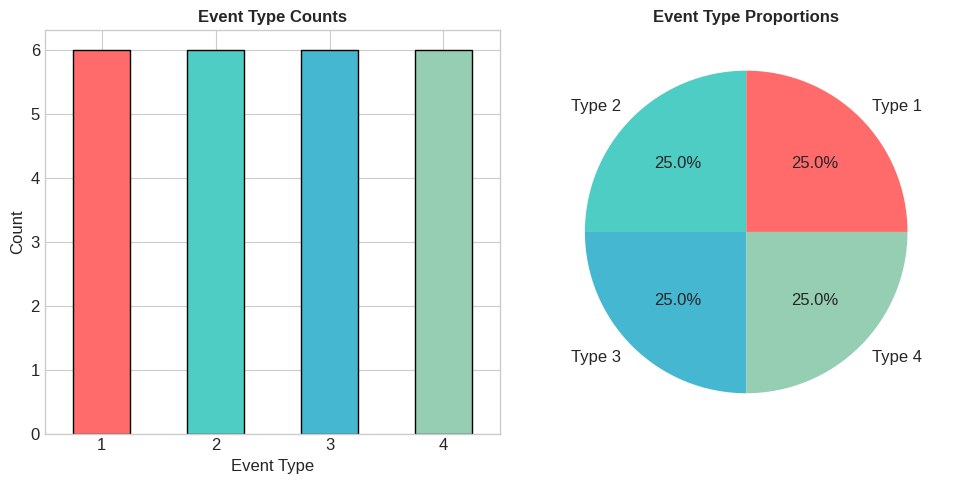

In [13]:
# Event type analysis
print("\n" + "=" * 60)
print("EVENT DATA - EVENT TYPE ANALYSIS")
print("=" * 60)

event_counts = event_data['Event_Type'].value_counts().sort_index()
print("\nEvent Type Distribution:")
print(event_counts)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
event_counts.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], edgecolor='black')
plt.title('Event Type Counts', fontsize=12, fontweight='bold')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.pie(event_counts.values, labels=[f'Type {i}' for i in event_counts.index], 
        autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Event Type Proportions', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# Event timing analysis
print("\n" + "=" * 60)
print("EVENT DATA - TIMING ANALYSIS")
print("=" * 60)

# Calculate inter-event intervals
event_data['Inter_Event_Interval'] = event_data['Sample_Index'].diff()

print(f"\nFirst event at sample: {event_data['Sample_Index'].iloc[0]}")
print(f"Last event at sample: {event_data['Sample_Index'].iloc[-1]}")
print(f"Total recording span: {event_data['Sample_Index'].iloc[-1] - event_data['Sample_Index'].iloc[0]} samples")

print(f"\nInter-Event Interval Statistics:")
print(event_data['Inter_Event_Interval'].describe())


EVENT DATA - TIMING ANALYSIS

First event at sample: 1
Last event at sample: 176641
Total recording span: 176640 samples

Inter-Event Interval Statistics:
count      23.0
mean     7680.0
std         0.0
min      7680.0
25%      7680.0
50%      7680.0
75%      7680.0
max      7680.0
Name: Inter_Event_Interval, dtype: float64


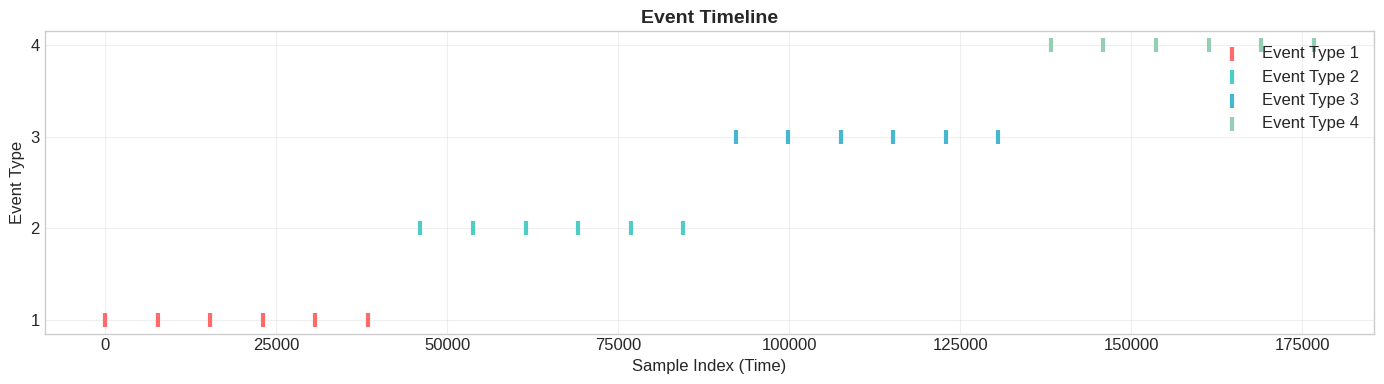

In [15]:
# Visualize event timeline
plt.figure(figsize=(14, 4))

colors = {1: '#FF6B6B', 2: '#4ECDC4', 3: '#45B7D1', 4: '#96CEB4'}
for event_type in event_data['Event_Type'].unique():
    mask = event_data['Event_Type'] == event_type
    plt.scatter(event_data.loc[mask, 'Sample_Index'], 
                [event_type] * mask.sum(),
                c=colors.get(event_type, 'gray'), 
                label=f'Event Type {event_type}',
                s=100, marker='|', linewidths=3)

plt.xlabel('Sample Index (Time)')
plt.ylabel('Event Type')
plt.title('Event Timeline', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.yticks(event_data['Event_Type'].unique())
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

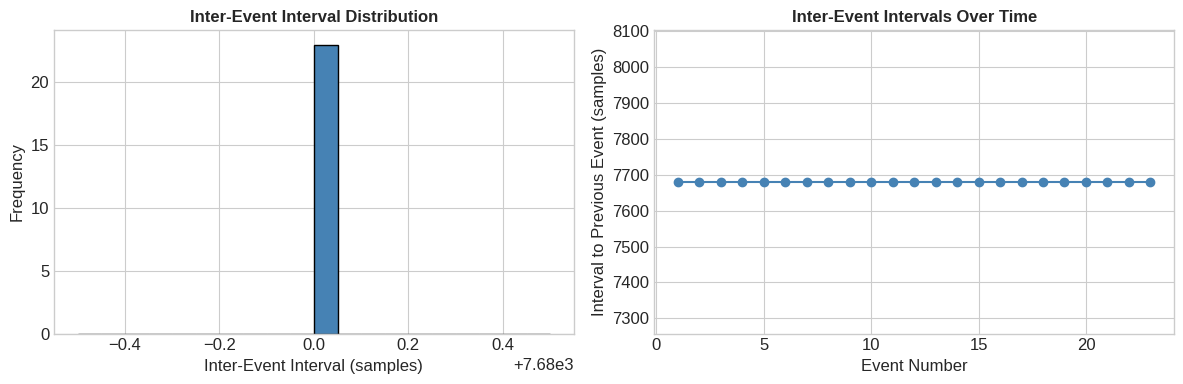

In [16]:
# Inter-event interval distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(event_data['Inter_Event_Interval'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Inter-Event Interval (samples)')
plt.ylabel('Frequency')
plt.title('Inter-Event Interval Distribution', fontsize=12, fontweight='bold')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(event_data)), event_data['Inter_Event_Interval'].dropna().values, 
         marker='o', linestyle='-', color='steelblue')
plt.xlabel('Event Number')
plt.ylabel('Interval to Previous Event (samples)')
plt.title('Inter-Event Intervals Over Time', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Electrode Coordinates Analysis (EEG_FEP_01_EEGxyz.csv)

This file contains the 3D spatial coordinates (X, Y, Z) of the EEG electrodes.

In [17]:
# Load electrode coordinate data
xyz_data = pd.read_csv('data/EEG_FEP_01_EEGxyz.csv', header=None)
xyz_data.columns = ['X', 'Y', 'Z']
xyz_data['Channel'] = [f'Ch_{i}' for i in range(len(xyz_data))]

print("=" * 60)
print("ELECTRODE COORDINATES - BASIC INFORMATION")
print("=" * 60)
print(f"\nShape: {xyz_data.shape}")
print(f"Number of electrodes: {len(xyz_data)}")
print(f"\nData types:\n{xyz_data.dtypes}")

ELECTRODE COORDINATES - BASIC INFORMATION

Shape: (32, 4)
Number of electrodes: 32

Data types:
X          float64
Y          float64
Z          float64
Channel     object
dtype: object


In [18]:
# Display all electrode coordinates
print("\n" + "=" * 60)
print("ELECTRODE COORDINATES - ALL POSITIONS")
print("=" * 60)
print(xyz_data)


ELECTRODE COORDINATES - ALL POSITIONS
           X          Y         Z Channel
0  -57.00000   30.66700   6.66670    Ch_0
1    0.66667   65.33300  22.33300    Ch_1
2  -49.66700   34.66700  29.33300    Ch_2
3    8.00000   54.33300  46.00000    Ch_3
4  -70.00000  -21.33300  -3.00000    Ch_4
5  -60.66700    9.33330  30.66700    Ch_5
6  -16.33300   35.33300  58.33300    Ch_6
7   38.33300   34.66700  47.66700    Ch_7
8   58.66700   26.33300  24.66700    Ch_8
9  -71.00000  -27.33300   0.66667    Ch_9
10 -38.33300   14.66700  60.66700   Ch_10
11  17.00000   23.33300  65.66700   Ch_11
12  65.00000    6.66670  29.66700   Ch_12
13 -69.00000  -44.66700  -8.66670   Ch_13
14 -68.00000  -27.33300  33.66700   Ch_14
15  -7.00000    5.33330  73.66700   Ch_15
16  57.00000   -0.33333  50.66700   Ch_16
17  70.00000  -15.33300  19.33300   Ch_17
18 -67.66700  -50.00000  16.33300   Ch_18
19 -27.33300  -17.66700  75.00000   Ch_19
20  24.66700   -9.33330  74.00000   Ch_20
21  68.00000  -23.66700  41.33300   C

In [19]:
# Statistical summary of coordinates
print("\n" + "=" * 60)
print("ELECTRODE COORDINATES - STATISTICAL SUMMARY")
print("=" * 60)
print(xyz_data[['X', 'Y', 'Z']].describe())


ELECTRODE COORDINATES - STATISTICAL SUMMARY
               X           Y          Z
count  32.000000   32.000000  32.000000
mean   -5.343730  -18.197917  36.812562
std    48.782692   45.332662  25.987105
min   -71.000000 -102.330000  -8.666700
25%   -51.500250  -48.250250  15.916500
50%    -3.166665  -19.500000  32.167000
75%    34.083500   16.833500  59.167000
max    70.000000   65.333000  76.667000


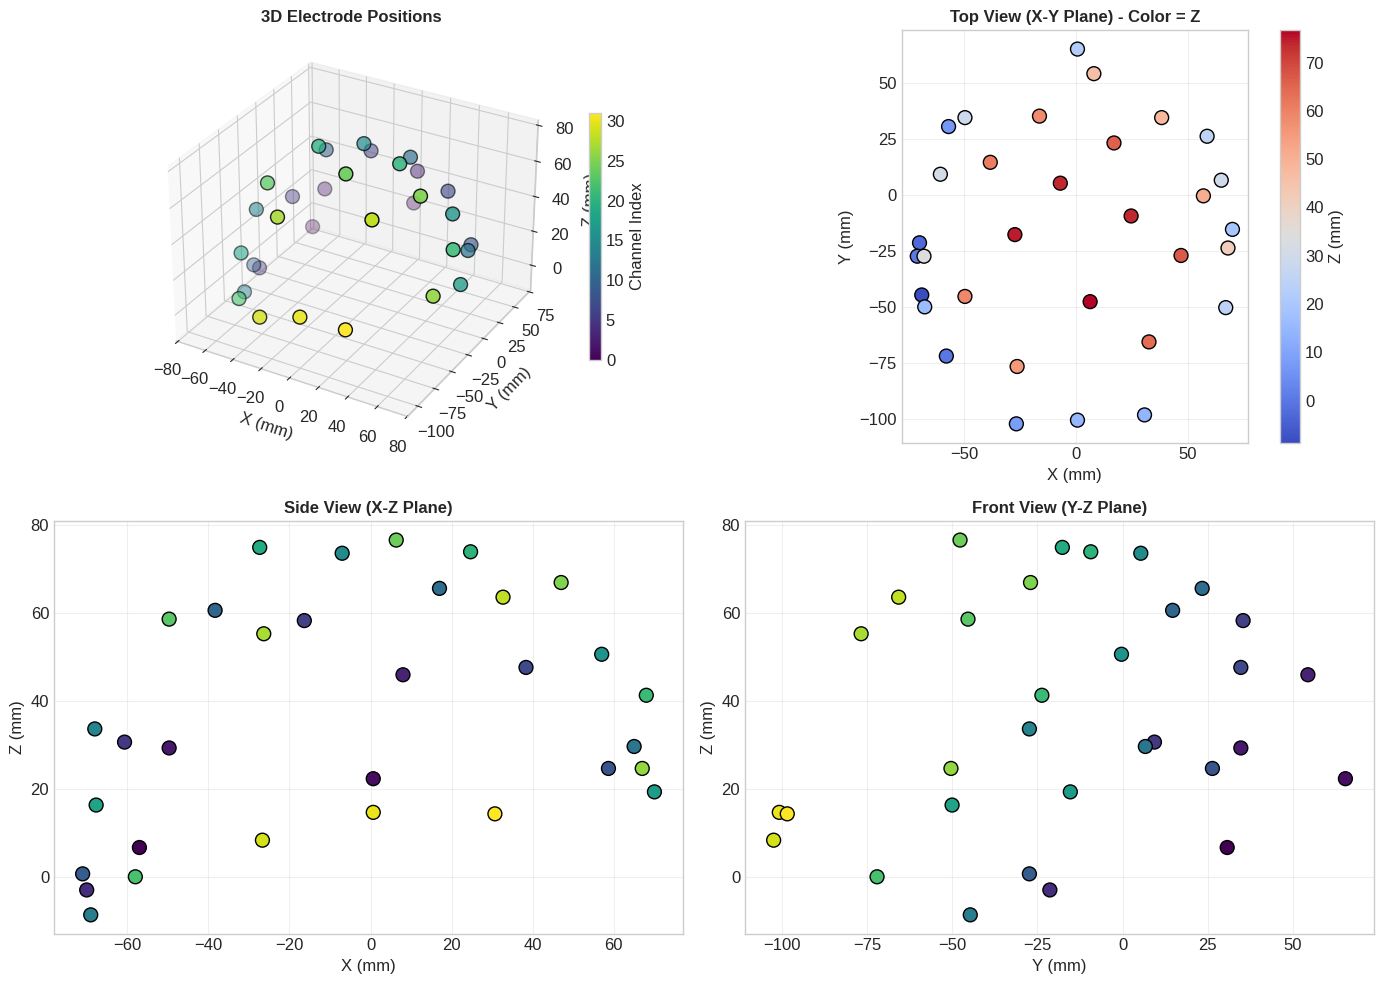

In [20]:
# 3D visualization of electrode positions
fig = plt.figure(figsize=(14, 10))

# 3D scatter plot
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
scatter = ax1.scatter(xyz_data['X'], xyz_data['Y'], xyz_data['Z'], 
                      c=range(len(xyz_data)), cmap='viridis', s=100, edgecolors='black')
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_zlabel('Z (mm)')
ax1.set_title('3D Electrode Positions', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Channel Index', shrink=0.6)

# Top view (X-Y plane)
ax2 = fig.add_subplot(2, 2, 2)
scatter2 = ax2.scatter(xyz_data['X'], xyz_data['Y'], c=xyz_data['Z'], 
                       cmap='coolwarm', s=100, edgecolors='black')
ax2.set_xlabel('X (mm)')
ax2.set_ylabel('Y (mm)')
ax2.set_title('Top View (X-Y Plane) - Color = Z', fontsize=12, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Z (mm)')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# Side view (X-Z plane)
ax3 = fig.add_subplot(2, 2, 3)
scatter3 = ax3.scatter(xyz_data['X'], xyz_data['Z'], c=range(len(xyz_data)), 
                       cmap='viridis', s=100, edgecolors='black')
ax3.set_xlabel('X (mm)')
ax3.set_ylabel('Z (mm)')
ax3.set_title('Side View (X-Z Plane)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Front view (Y-Z plane)
ax4 = fig.add_subplot(2, 2, 4)
scatter4 = ax4.scatter(xyz_data['Y'], xyz_data['Z'], c=range(len(xyz_data)), 
                       cmap='viridis', s=100, edgecolors='black')
ax4.set_xlabel('Y (mm)')
ax4.set_ylabel('Z (mm)')
ax4.set_title('Front View (Y-Z Plane)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Calculate inter-electrode distances
from scipy.spatial.distance import pdist, squareform

coords = xyz_data[['X', 'Y', 'Z']].values
distance_matrix = squareform(pdist(coords))
distance_df = pd.DataFrame(distance_matrix, 
                           index=xyz_data['Channel'], 
                           columns=xyz_data['Channel'])

print("\n" + "=" * 60)
print("ELECTRODE COORDINATES - INTER-ELECTRODE DISTANCES")
print("=" * 60)

# Get upper triangle values (excluding diagonal)
upper_tri = distance_matrix[np.triu_indices(len(distance_matrix), k=1)]

print(f"\nDistance Statistics (mm):")
print(f"  Min distance: {upper_tri.min():.2f}")
print(f"  Max distance: {upper_tri.max():.2f}")
print(f"  Mean distance: {upper_tri.mean():.2f}")
print(f"  Std distance: {upper_tri.std():.2f}")


ELECTRODE COORDINATES - INTER-ELECTRODE DISTANCES

Distance Statistics (mm):
  Min distance: 7.10
  Max distance: 170.45
  Mean distance: 94.33
  Std distance: 36.37


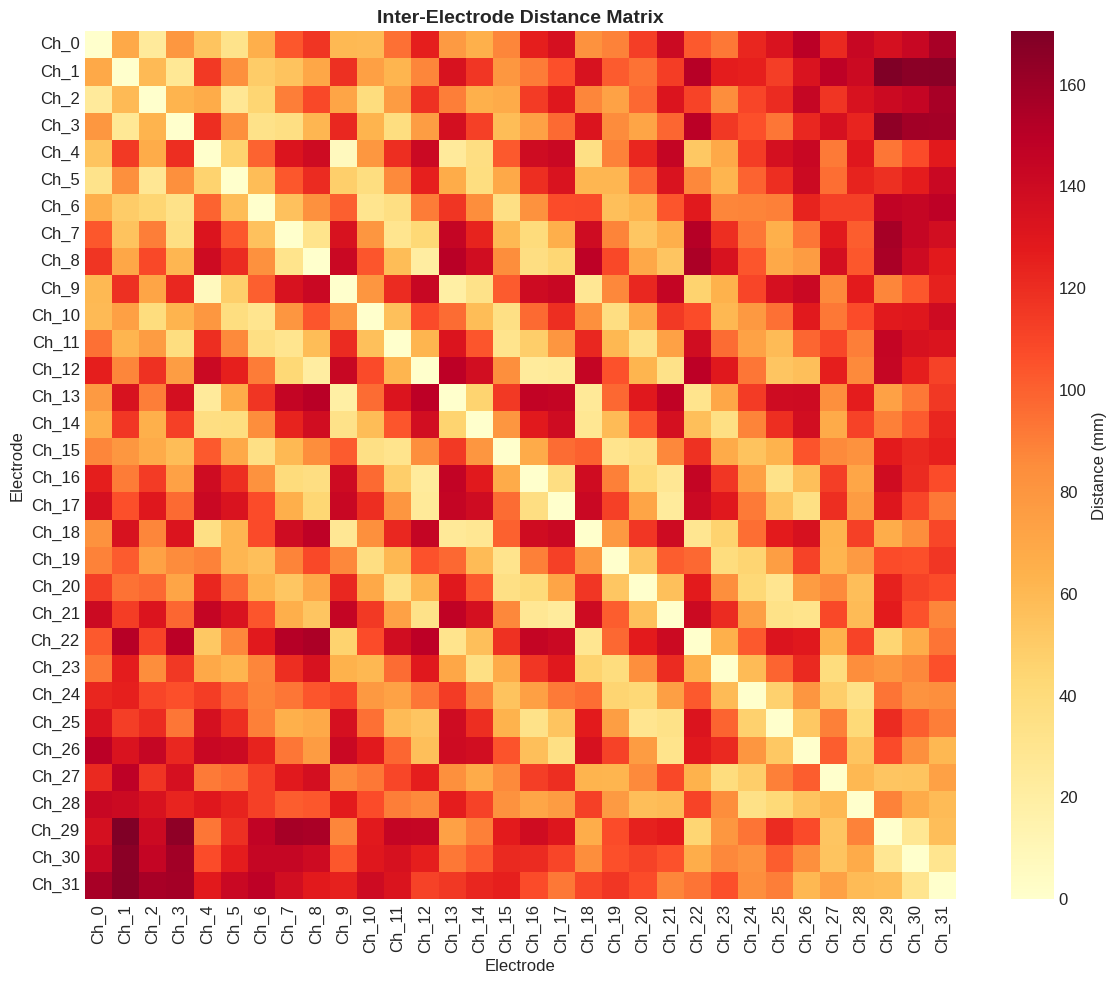

In [22]:
# Distance matrix heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(distance_df, cmap='YlOrRd', annot=False, 
            cbar_kws={'label': 'Distance (mm)'})
plt.title('Inter-Electrode Distance Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Electrode')
plt.ylabel('Electrode')
plt.tight_layout()
plt.show()

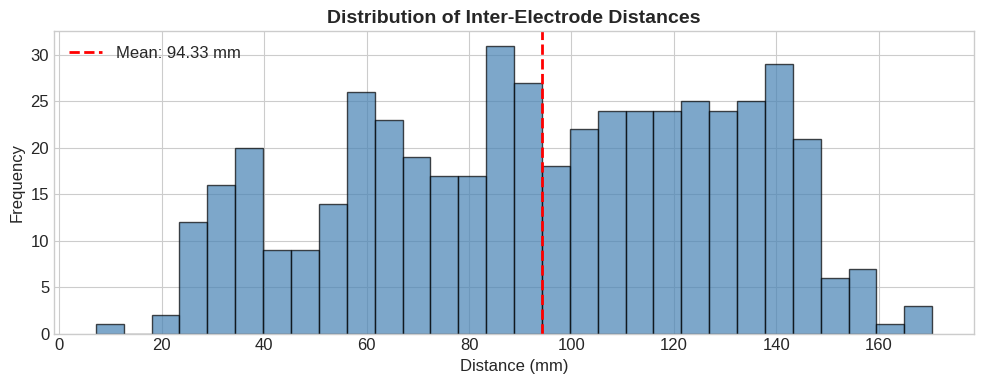

In [23]:
# Distribution of inter-electrode distances
plt.figure(figsize=(10, 4))
plt.hist(upper_tri, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(upper_tri.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {upper_tri.mean():.2f} mm')
plt.xlabel('Distance (mm)')
plt.ylabel('Frequency')
plt.title('Distribution of Inter-Electrode Distances', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Combined Analysis: Integrating All Three Datasets

In [24]:
# Summary of all datasets
print("=" * 70)
print("COMBINED SUMMARY OF ALL DATASETS")
print("=" * 70)

print(f"\n{'Dataset':<30} {'Shape':<20} {'Description'}")
print("-" * 70)
print(f"{'EEG Data':<30} {str(eeg_data.shape):<20} {'Time series from 31 channels'}")
print(f"{'Event Data':<30} {str(event_data.shape):<20} {'Event markers with timestamps'}")
print(f"{'Electrode Coordinates':<30} {str(xyz_data.shape):<20} {'3D positions (X, Y, Z)'}")

print(f"\n\nKey Observations:")
print(f"  • EEG recording has {eeg_data.shape[0]:,} time samples across {eeg_data.shape[1]} channels")
print(f"  • Number of electrodes in xyz file: {len(xyz_data)}")
print(f"  • Total events recorded: {len(event_data)}")
print(f"  • Event types: {sorted(event_data['Event_Type'].unique())}")

COMBINED SUMMARY OF ALL DATASETS

Dataset                        Shape                Description
----------------------------------------------------------------------
EEG Data                       (184320, 31)         Time series from 31 channels
Event Data                     (24, 3)              Event markers with timestamps
Electrode Coordinates          (32, 4)              3D positions (X, Y, Z)


Key Observations:
  • EEG recording has 184,320 time samples across 31 channels
  • Number of electrodes in xyz file: 32
  • Total events recorded: 24
  • Event types: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


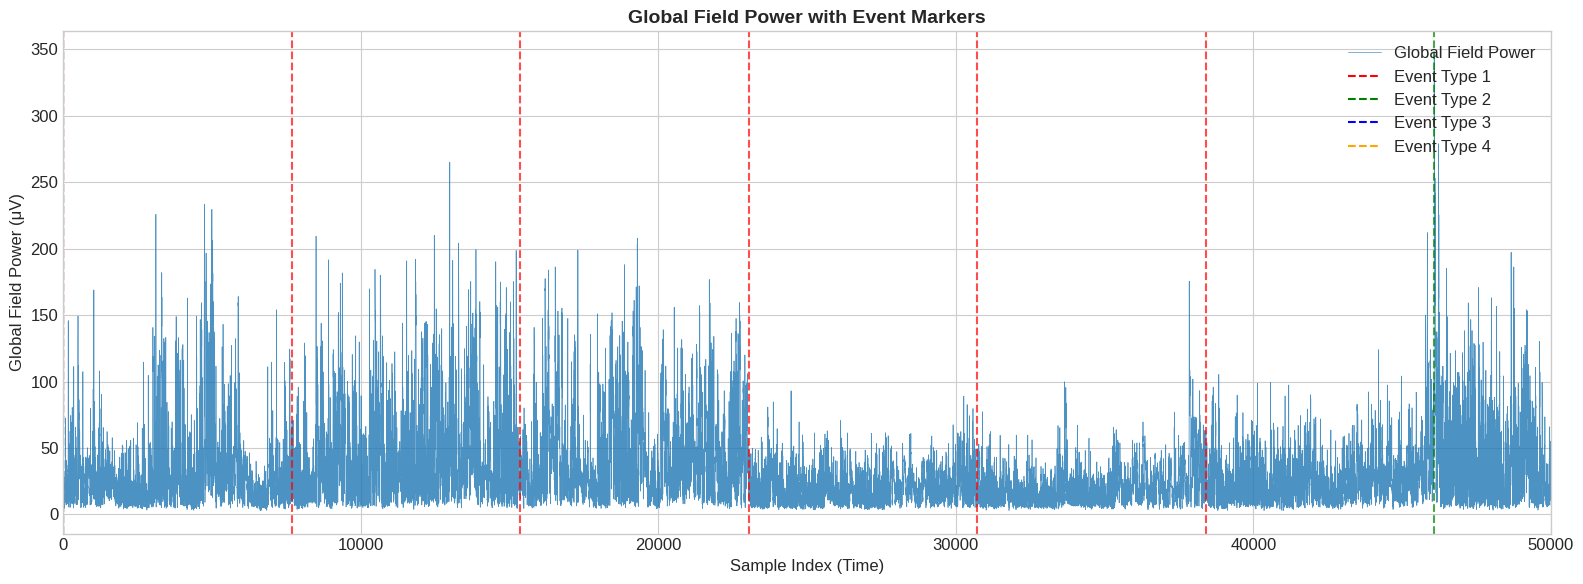

In [25]:
# Overlay events on EEG signal (Grand Average)
plt.figure(figsize=(16, 6))

# Calculate global field power (GFP) - std across channels
gfp = eeg_data.std(axis=1)

plt.plot(gfp.values[:50000], linewidth=0.5, alpha=0.8, label='Global Field Power')

# Mark events
colors = {1: 'red', 2: 'green', 3: 'blue', 4: 'orange'}
for _, row in event_data.iterrows():
    if row['Sample_Index'] < 50000:  # Only plot events within visible range
        plt.axvline(x=row['Sample_Index'], color=colors.get(row['Event_Type'], 'gray'), 
                    linestyle='--', alpha=0.7, linewidth=1.5)

# Create legend for event types
for event_type, color in colors.items():
    if event_type in event_data['Event_Type'].values:
        plt.axvline(x=-1, color=color, linestyle='--', label=f'Event Type {event_type}')

plt.xlabel('Sample Index (Time)')
plt.ylabel('Global Field Power (μV)')
plt.title('Global Field Power with Event Markers', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.xlim(0, 50000)
plt.tight_layout()
plt.show()

In [26]:
# Spatial distribution of channel variance (if channel count matches)
if len(xyz_data) == eeg_data.shape[1]:
    fig = plt.figure(figsize=(14, 5))
    
    # Calculate channel variance
    variances = eeg_data.var().values
    
    # Top view with variance as color
    ax1 = fig.add_subplot(1, 2, 1)
    scatter = ax1.scatter(xyz_data['X'], xyz_data['Y'], c=variances, 
                          cmap='hot', s=200, edgecolors='black', linewidths=1.5)
    ax1.set_xlabel('X (mm)')
    ax1.set_ylabel('Y (mm)')
    ax1.set_title('Spatial Distribution of Signal Variance (Top View)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax1, label='Variance')
    ax1.set_aspect('equal')
    
    # 3D view with variance as color
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    scatter2 = ax2.scatter(xyz_data['X'], xyz_data['Y'], xyz_data['Z'], 
                           c=variances, cmap='hot', s=150, edgecolors='black')
    ax2.set_xlabel('X (mm)')
    ax2.set_ylabel('Y (mm)')
    ax2.set_zlabel('Z (mm)')
    ax2.set_title('3D Spatial Variance Distribution', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Note: Channel count mismatch - EEG has {eeg_data.shape[1]} channels, XYZ has {len(xyz_data)} electrodes")

Note: Channel count mismatch - EEG has 31 channels, XYZ has 32 electrodes


In [27]:
# Final summary statistics
print("\n" + "=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print("\n📊 EEG DATA SUMMARY:")
print(f"   • Recording duration: {eeg_data.shape[0]:,} samples")
print(f"   • Number of channels: {eeg_data.shape[1]}")
print(f"   • Global amplitude range: [{eeg_data.min().min():.2f}, {eeg_data.max().max():.2f}] μV")
print(f"   • Mean signal amplitude: {eeg_data.mean().mean():.2f} μV")
print(f"   • Missing values: {eeg_data.isnull().sum().sum()}")

print("\n📌 EVENT DATA SUMMARY:")
print(f"   • Total events: {len(event_data)}")
print(f"   • Event types: {len(event_data['Event_Type'].unique())}")
print(f"   • Events per type: {dict(event_data['Event_Type'].value_counts().sort_index())}")
print(f"   • Mean inter-event interval: {event_data['Inter_Event_Interval'].mean():.0f} samples")

print("\n📍 ELECTRODE COORDINATES SUMMARY:")
print(f"   • Number of electrodes: {len(xyz_data)}")
print(f"   • X range: [{xyz_data['X'].min():.2f}, {xyz_data['X'].max():.2f}] mm")
print(f"   • Y range: [{xyz_data['Y'].min():.2f}, {xyz_data['Y'].max():.2f}] mm")
print(f"   • Z range: [{xyz_data['Z'].min():.2f}, {xyz_data['Z'].max():.2f}] mm")
print(f"   • Mean inter-electrode distance: {upper_tri.mean():.2f} mm")

print("\n" + "=" * 70)
print("EDA COMPLETE!")
print("=" * 70)


FINAL EDA SUMMARY

📊 EEG DATA SUMMARY:
   • Recording duration: 184,320 samples
   • Number of channels: 31
   • Global amplitude range: [-39202.00, 125860.00] μV
   • Mean signal amplitude: -0.12 μV
   • Missing values: 0

📌 EVENT DATA SUMMARY:
   • Total events: 24
   • Event types: 4
   • Events per type: {1: np.int64(6), 2: np.int64(6), 3: np.int64(6), 4: np.int64(6)}
   • Mean inter-event interval: 7680 samples

📍 ELECTRODE COORDINATES SUMMARY:
   • Number of electrodes: 32
   • X range: [-71.00, 70.00] mm
   • Y range: [-102.33, 65.33] mm
   • Z range: [-8.67, 76.67] mm
   • Mean inter-electrode distance: 94.33 mm

EDA COMPLETE!
